# Differential methylation of genes

This notebook identifies differentially methylated genes between MeD-seq samples.

## Input

- DCM scores per gene body site available from GEO (GSE304236_DCMscores.genesites.txt)
- Scanpy object generated in notebook 6 (scRNA.h5ad)

## Output

- Tables S4 and S5. Differentially DCM-methylated genes
- Figure 3d and f: Volcano plots of differentially methylated genes
- Figure 3e and g: UCell scores of differentially methylated genes in scRNA-seq dataset
- Figure S7a and S7c. UMAPS with UCell scores
- Figure S7b and S7d. Dotplots of top DDM genes
- Figure 3c. Violin plot with DCM scores per DCM site for ZFP42 and EOMES

## Packages

In [1]:
# General
from pathlib import Path
import numpy as np
import pandas as pd

# Plotting
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from IPython.display import SVG, display

# Statistics
import scipy
from scipy.stats import median_abs_deviation, mannwhitneyu
from statsmodels.stats.multitest import multipletests
import statistics

# scRNA-seq analysis
import warnings
warnings.simplefilter("ignore", category=(UserWarning, FutureWarning, DeprecationWarning))
import scanpy as sc
import pyucell as uc

# Plot settings
plt.rcParams.update({"figure.figsize": (10, 10), "svg.fonttype": "none", "font.family": "Arial"})
sc.set_figure_params(format="svg", dpi_save=300, figsize=(10,10), vector_friendly=False)
sns.set_style("ticks")

In [2]:
# Directories: update these paths as needed
input_dir = "../Input/GEO"   # folder where GEO data is stored
output_dir = "../Output"    # folder where output files will be saved
Path(output_dir).mkdir(parents=True, exist_ok=True)

# Settings
labels = ["iPSC", "DE", "PGT"]              # custom labels
colors = ["#264653", "#E9C46A", "#E76F51"]  # colors to use
palette = dict(zip(labels, colors))         # palette for plots

## Supplemental tables 4 and 5. Differentially DCM-methylated genes

In [3]:
counts = pd.read_csv(f"{input_dir}/GSE304236_DCMscores.genesites.txt", sep="\t", header=0, index_col=0)
for sample in ["iPSC.nodox", "iPSC.chase", "iPSC.dox", "DE.chase", "DE.dox", "PGT.chase"]:
    counts[sample] = counts[sample].apply(lambda x: [float(i) for i in x.split(",")])
display(counts)

,iPSC.nodox,iPSC.chase,iPSC.dox,DE.chase,DE.dox,PGT.chase,GeneName,NrSites
GeneID,,,,,,,,
ENSG00000000003,"[0.0095429849250612, 0.0, 0.0, 0.0095429849250...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.021354493001947698, 0.05803664734947259, 0....","[0.0, 0.0, 0.0, 0.12362132499694485, 0.0, 0.0,...","[0.011100829195214266, 0.05999190706608504, 0....","[0.0, 0.0, 0.0, 0.03290758971931363, 0.0, 0.0,...",TSPAN6,38
ENSG00000000005,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.00785891...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0416831867240707, 0.0, 0.0, 0.00930082...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.06080380...","[0.0, 0.0251288324627852, 0.0, 0.0333024875856...","[0.030057022193231666, 0.0, 0.0, 0.0, 0.0, 0.0...",TNMD,41
ENSG00000000419,"[0.0, 0.007858915368142, 0.0, 0.0, 0.0, 0.0, 0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.093...","[0.07561250744806076, 0.08818733517010317, 0.0...","[0.05821059613238707, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.02356824544512823, 0.024934832499827933, 0....","[0.0, 0.0, 0.0, 0.030057022193231666, 0.034450...",DPM1,85
ENSG00000000457,"[0.0095429849250612, 0.0, 0.0095429849250612, ...","[0.04654568322711666, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.015327661345577066, 0.0810581511436023, 0.0...","[0.0, 0.0, 0.05821059613238707, 0.0, 0.0, 0.0,...","[0.012467416249913967, 0.03779024867565647, 0....","[0.0, 0.03290758971931363, 0.0, 0.0, 0.0, 0.03...",SCYL3,124
ENSG00000000460,"[0.0, 0.0, 0.0, 0.0, 0.0180695843409495, 0.0, ...","[0.0, 0.10798722435643904, 0.06144154112932237...","[0.009300829689206466, 0.0399561523803607, 0.0...","[0.06080380225004323, 0.11901439838243029, 0.1...","[0.024934832499827933, 0.02356824544512823, 0....","[0.03290758971931363, 0.03290758971931363, 0.0...",C1orf112,562
...,...,...,...,...,...,...,...,...
ENSG00000291263,"[0.0, 0.0, 0.0, 0.0, 0.007858915368142, 0.0102...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.029048335450500267, 0.0564896836603467, 0.0...","[0.0, 0.0, 0.0, 0.06080380225004323, 0.0, 0.0,...","[0.024934832499827933, 0.07089873629834204, 0....","[0.0, 0.0629646119125453, 0.09587220163185893,...",SMG1P7,14
ENSG00000291266,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0556320376761144, 0.0, 0.0, 0.0, 0.11707357...","[0.10689251211279478, 0.06143069248536451, 0.0...","[0.0, 0.0, 0.0, 0.0, 0.1818319211293319, 0.062...","[0.012467416249913967, 0.048891077870870735, 0...","[0.0, 0.06011404438646333, 0.03005702219323166...",SMG1P5,222
ENSG00000291280,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.111...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.06303767...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.06080380...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.12252298...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.030057022193231666...",ANKRD20A11P,105


In [4]:
pseudocount = 0.001
de_dfs = {}

for comparison, x, y in [["dox", "DE.dox", "iPSC.dox"], ["chase", "PGT.chase", "DE.chase"]]:
    de_df = counts.copy()

    # Calculate p-value (paired t-test) and log2 fold change
    for index, row in de_df.iterrows():
        de_df.loc[index, "pval"] = scipy.stats.ttest_rel(row[x], row[y]).pvalue     
        de_df.loc[index, "log2FoldChange"] = np.log2((statistics.mean(row[x]) + pseudocount) /
                                                     (statistics.mean(row[y]) + pseudocount))

    # Correct for multiple testing
    de_df = de_df[de_df["pval"].notna()]
    de_df["padj"] = multipletests(de_df["pval"], method="fdr_bh")[1]
    de_df["-log10(adjusted P-value)"] = -np.log10(de_df["padj"])
    de_df = de_df.sort_values("padj", ascending=True)

    # Add column with significance status (alpha < 0.05, absolute log2 fold change > 0.05)
    de_df["Category"] = np.select([(de_df["padj"] < 0.05) & (de_df["log2FoldChange"] > 0.5), 
                                   (de_df["padj"] < 0.05) & (de_df["log2FoldChange"] < -0.5)], 
                                  [x, y], default="Not significant")
    print(de_df["Category"].value_counts())
    
    de_dfs[comparison] = de_df

Category
Not significant    21257
DE.dox              1909
iPSC.dox            1643
Name: count, dtype: int64
Category
Not significant    23493
PGT.chase            949
DE.chase             361
Name: count, dtype: int64


In [5]:
for i, (comparison, table) in enumerate([["dox", 4], ["chase", 5]]):
    de_df = de_dfs[comparison].copy()
    de_df["GeneID"] = de_df.index
    de_df = de_df[["GeneID", "GeneName", "NrSites", "log2FoldChange", "pval", "padj", "Category"]]
    de_df = de_df[de_df["Category"] != "Not significant"]
    de_df = de_df.sort_values("log2FoldChange")
    display(de_df)
    de_df.to_csv(f"{output_dir}/SupplementalTable{table}.txt", sep="\t", index=False)

,GeneID,GeneName,NrSites,log2FoldChange,pval,padj,Category
GeneID,,,,,,,
ENSG00000231064,ENSG00000231064,THBS3-AS1,88,-2.051148,2.568757e-14,8.611931e-13,iPSC.dox
ENSG00000143494,ENSG00000143494,VASH2,229,-1.849975,3.965464e-37,8.862990e-35,iPSC.dox
ENSG00000255151,ENSG00000255151,GLYATL1B,16,-1.835169,1.715960e-02,4.478632e-02,iPSC.dox
ENSG00000254399,ENSG00000254399,GLYATL1P4,15,-1.830998,2.513318e-03,9.030110e-03,iPSC.dox
ENSG00000250529,ENSG00000250529,LINC02121,38,-1.725051,4.528093e-08,5.303940e-07,iPSC.dox
...,...,...,...,...,...,...,...
ENSG00000164736,ENSG00000164736,SOX17,17,2.410677,1.354968e-04,7.181242e-04,DE.dox
ENSG00000242159,ENSG00000242159,ABCF2P1,13,2.468569,3.733717e-04,1.745427e-03,DE.dox
ENSG00000237902,ENSG00000237902,TSPY21P,16,2.493852,3.056307e-03,1.065541e-02,DE.dox


,GeneID,GeneName,NrSites,log2FoldChange,pval,padj,Category
GeneID,,,,,,,
ENSG00000260984,ENSG00000260984,FGFR3P5,41,-2.246651,0.003465,0.037352,DE.chase
ENSG00000284690,ENSG00000284690,CD300H,35,-2.042887,0.000718,0.012425,DE.chase
ENSG00000260746,ENSG00000260746,KIF18BP1,62,-2.026020,0.001695,0.023301,DE.chase
ENSG00000170613,ENSG00000170613,GARIN3,24,-2.019261,0.004950,0.047386,DE.chase
ENSG00000277988,ENSG00000277988,FAM30B,16,-1.928463,0.000698,0.012191,DE.chase
...,...,...,...,...,...,...,...
ENSG00000248730,ENSG00000248730,EGFLAM-AS4,30,2.680031,0.000050,0.001774,PGT.chase
ENSG00000129514,ENSG00000129514,FOXA1,16,2.878168,0.001655,0.022888,PGT.chase
ENSG00000154451,ENSG00000154451,GBP5,38,2.900813,0.001718,0.023448,PGT.chase


## Figure 3d and f: Volcano plots of differentially methylated genes

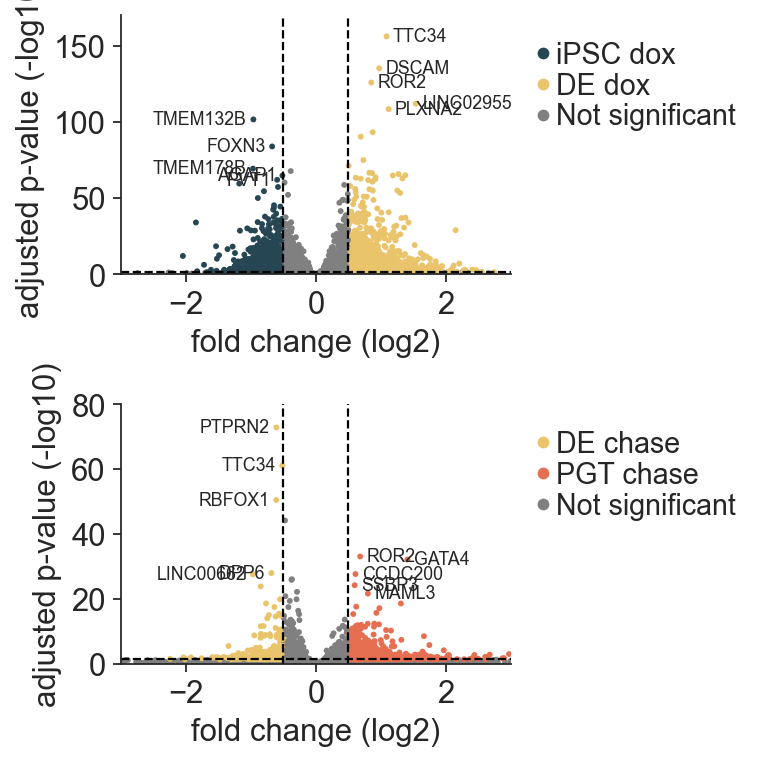

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(5, 5))

for i, (comparison, x, y) in enumerate([["dox", "DE.dox", "iPSC.dox"], ["chase", "PGT.chase", "DE.chase"]]):
    de_df = de_dfs[comparison]

    # Volcano plots
    volcano_palette = {x: palette[x.split(".")[0]], y: palette[y.split(".")[0]], "Not significant": "gray"}
    sns.scatterplot(data=de_df[::-1], x="log2FoldChange", y="-log10(adjusted P-value)", hue="Category",
                    marker="o", s=7, linewidth=0, legend=True, palette=volcano_palette, ax=axes[i])

    # Add labels of top 15 labeled genes
    for _, r in de_df[de_df["Category"] == x].head(5).iterrows():
        axes[i].text(x=r["log2FoldChange"] + 0.1, y=r["-log10(adjusted P-value)"], s=r["GeneName"], fontsize=8, ha="left", va="center")
    for _, r in de_df[de_df["Category"] == y].head(5).iterrows():
        axes[i].text(x=r["log2FoldChange"] - 0.1, y=r["-log10(adjusted P-value)"], s=r["GeneName"], fontsize=8, ha="right", va="center")

    # Add axis labels and threshold lines
    axes[i].set(xlabel="fold change (log2)", ylabel="adjusted p-value (-log10)")
    axes[i].axhline(-np.log10(0.05), color="black", linestyle="--", linewidth=1)
    axes[i].axvline(0.5, color="black", linestyle="--", linewidth=1)
    axes[i].axvline(-0.5, color="black", linestyle="--", linewidth=1)

    # Add legend
    handles, labels = axes[i].get_legend_handles_labels()
    labels = [label.replace(".", " ") for label in labels]
    axes[i].legend(handles[::-1], labels[::-1], loc="upper left", bbox_to_anchor=(1, 1), 
                   title="", frameon=False, markerscale=2, handletextpad=0.2, labelspacing=0.1)

# Set axes ranges
axes[0].set(xlim=(-3, 3), ylim=(0, 170))
axes[1].set(xlim=(-3, 3), ylim=(0, 80))

sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/Figure3df.svg", format="svg")
plt.show()

## Figure 3e and g: UCell scores of differentially methylated genes in scRNA-seq dataset

AnnData object with n_obs × n_vars = 1022 × 36693
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'Celltype', 'outlier'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts-DE', 'mean_counts-DE', 'log1p_mean_counts-DE', 'pct_dropout_by_counts-DE', 'total_counts-DE', 'log1p_total_counts-DE', 'n_cells_by_counts-PGT', 'mean_counts-PGT', 'log1p_mean_counts-PGT', 'pct_dropout_by_counts-PGT', 'total_counts-PGT', 'log1p_total_counts-PGT', 'n_cells_by_counts-iPSC', 'mean_counts-iPSC', 'log1p_mean_counts-iPSC', 'pct_dropout_by_counts-iPSC', 'total_counts-iPSC', 'log1p_total_counts-iPSC', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'Celltype', 'Celltype_colors', 'hvg', 'log1p', 'neighbors', 'pca'
    obsm: 'Harmo

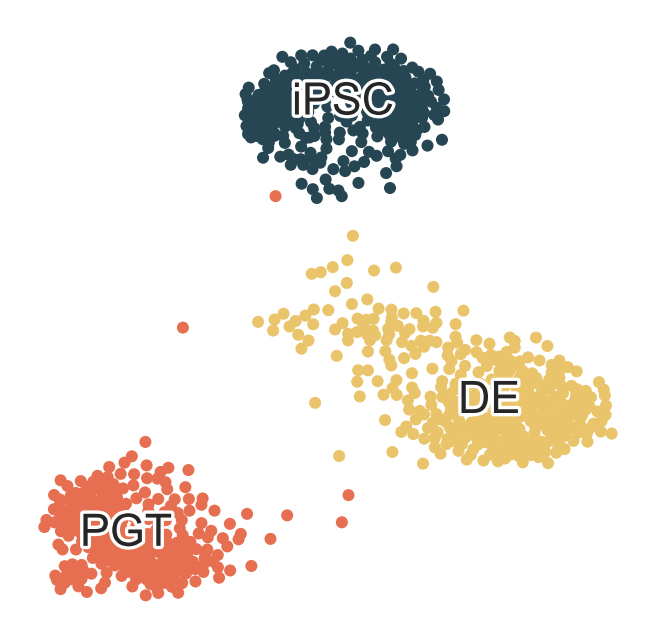

In [7]:
# Load scRNA-seq dataset
adata = sc.read_h5ad(f"{output_dir}/scRNA.h5ad")
print(adata)

with plt.rc_context({"figure.figsize": (5, 5)}):
    sc.pl.embedding(adata, basis="Harmony", frameon=False, color="Celltype", palette=palette, title="",
                    legend_loc="on data", legend_fontsize="x-large", legend_fontweight="normal", legend_fontoutline=3, show=True)

In [8]:
nr_genes = []
for i, (comparison, x, y) in enumerate([["dox", "DE.dox", "iPSC.dox"], ["chase", "PGT.chase", "DE.chase"]]):
    de_df = de_dfs[comparison]

    for j, sign in enumerate([y, x]):
        
        # Get list of significant genes
        sign_genes = de_df[de_df["Category"] == sign]["GeneName"]
        nr_genes.append(len(sign_genes))
        sign_genes = [gene for gene in sign_genes if gene in adata.var_names]

        # Calculate UCell scores
        uc.compute_ucell_scores(adata, signatures={sign: sign_genes})

print(nr_genes)

/home/beatrice/miniconda3/envs/hDCM-TM/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/beatrice/miniconda3/envs/hDCM-TM/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/beatrice/miniconda3/envs/hDCM-TM/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/beatrice/miniconda3/envs/hDCM-TM/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/beatrice/miniconda3/envs/hDCM-TM/lib/python3.10/site-packages/anndata/utils.py:434: 

[1643, 1909, 361, 949]


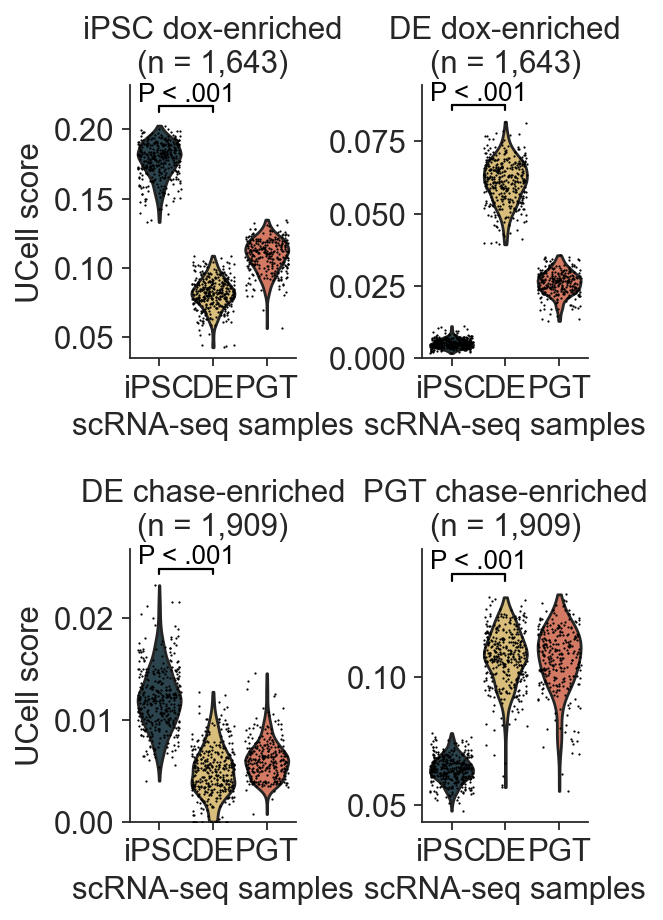

In [9]:
fig, axs = plt.subplots(2, 2, figsize=(4, 6))

for i, (comparison, x, y) in enumerate([["dox", "DE.dox", "iPSC.dox"], ["chase", "PGT.chase", "DE.chase"]]):
    for j, sign in enumerate([y, x]):
        
        # Plot UCell scores in violin
        sc.pl.violin(adata, f"{sign}_UCell", groupby="Celltype", jitter=0.4, show=False, ax=axs[i,j])
        axs[i,j].set(title=sign.replace(".", " ") + f"-enriched\n(n = {nr_genes[i]:,})", 
                     xlabel="scRNA-seq samples", ylabel="", ylim=(None, axs[i,j].get_ylim()[1]*1.1))
        if axs[i,j].get_ylim()[0] < 0:
                axs[i,j].set_ylim(bottom=0)
        
        # Calculate significance between cell types
        iPSC_values = adata[adata.obs["Celltype"] == "iPSC"].obs[f"{sign}_UCell"].tolist()
        DE_values = adata[adata.obs["Celltype"] == "DE"].obs[f"{sign}_UCell"].tolist()
        stat, p_value = scipy.stats.mannwhitneyu(iPSC_values, DE_values, alternative="two-sided")

        # Add significance to violin
        formatted_p = "P < .001" if p_value < 0.001 else "n.s." if p_value >= 0.05 else f"{p_value:.3f}"
        y_loc = adata[adata.obs["Celltype"].isin(["iPSC", "DE"])].obs[f"{sign}_UCell"].max() * 1.07
        axs[i,j].plot((0, 1), (y_loc, y_loc), color="black", linewidth=1)   # horizontal line
        axs[i,j].plot((0, 0), (y_loc*0.98, y_loc), color="black", linewidth=1)   # left vertical line
        axs[i,j].plot((1, 1), (y_loc*0.98, y_loc), color="black", linewidth=1)   # right vertical line
        axs[i,j].text(0.5, y_loc, formatted_p, ha="center", va="bottom", color="black", fontsize="small")

    axs[i, 0].set(ylabel=f"UCell score")

sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/Figure3eg.svg", format="svg")
plt.show()

## Figure S7a and S7c. UMAPS with UCell scores

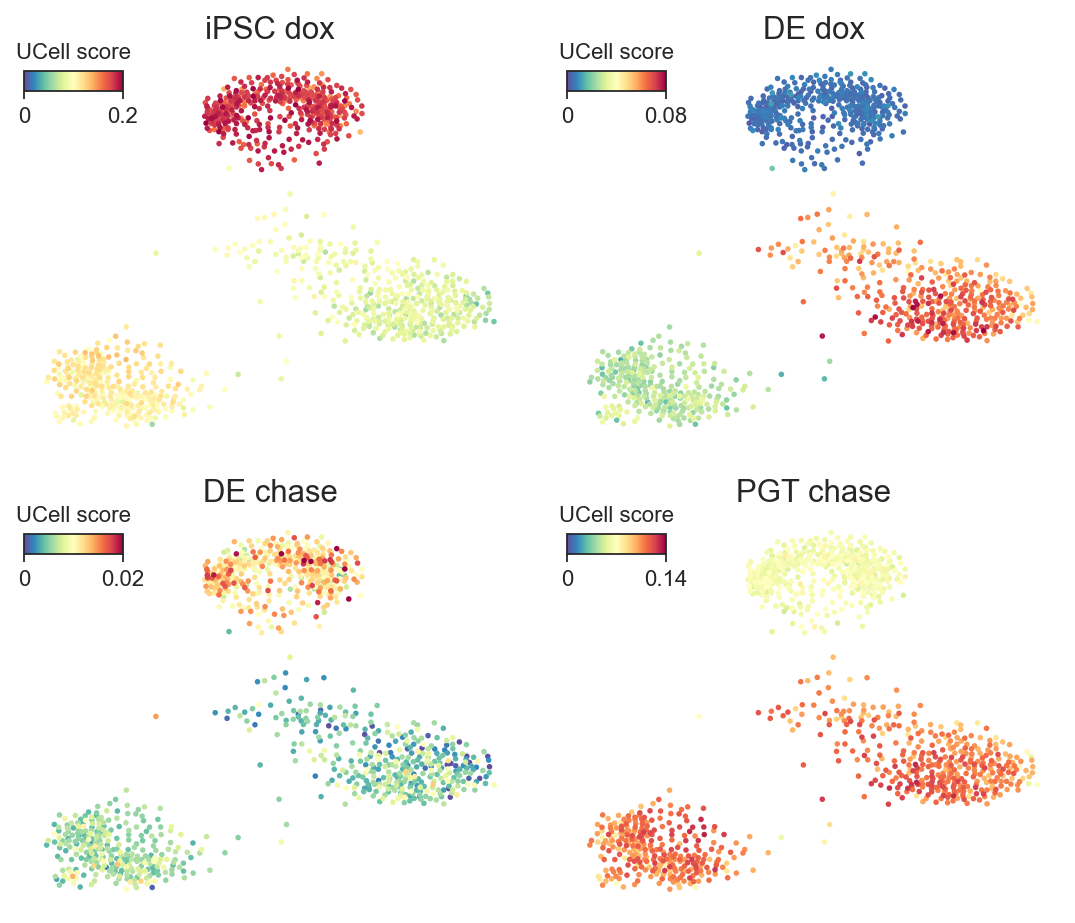

In [10]:
vmax = {"DE.dox": 0.08, "iPSC.dox": 0.2, "PGT.chase": 0.14, "DE.chase": 0.02}

fig, axs = plt.subplots(2, 2, figsize=(7, 6))

for i, (comparison, x, y) in enumerate([["dox", "DE.dox", "iPSC.dox"], ["chase", "PGT.chase", "DE.chase"]]):
    for j, sign in enumerate([y, x]):
        # UMAP with UCell scores
        sc.pl.embedding(adata, basis="Harmony", color=f"{sign}_UCell", title=sign.replace(".", " "),
                        cmap="Spectral_r", colorbar_loc=None, s=25, vmin=0, vmax=vmax[sign], frameon=False, show=False, ax=axs[i,j])

        # Add custom colorbar
        cax = axs[i,j].inset_axes([0.0, 0.9, 0.2, 0.05])
        sm = matplotlib.cm.ScalarMappable(norm=plt.Normalize(vmin=0, vmax=vmax[sign]), cmap="Spectral_r")
        cbar = fig.colorbar(sm, cax=cax, orientation="horizontal", ticks=[0, vmax[sign]], label="")
        cbar.ax.set_xticklabels(['0', vmax[sign]], fontsize=10)
        cbar.ax.set_title("UCell score", fontsize=10)

sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/SupplementalFigure7ac.svg", format="svg")
plt.show()

## Figure S7b and S7d. Dotplots of top DDM genes

In [11]:
# Prepare colormap and filtered adata
spectral_cmap = plt.cm.Spectral_r
sub_spectral_cmap = matplotlib.colors.LinearSegmentedColormap.from_list("Spectral_r_truncated", spectral_cmap(np.linspace(0.5, 1, 256)))

adata_filtered = adata.copy()
sc.pp.filter_genes(adata_filtered, min_cells=20)
print(adata_filtered)

AnnData object with n_obs × n_vars = 1022 × 14677
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'Celltype', 'outlier', 'iPSC.dox_UCell', 'DE.dox_UCell', 'DE.chase_UCell', 'PGT.chase_UCell'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts-DE', 'mean_counts-DE', 'log1p_mean_counts-DE', 'pct_dropout_by_counts-DE', 'total_counts-DE', 'log1p_total_counts-DE', 'n_cells_by_counts-PGT', 'mean_counts-PGT', 'log1p_mean_counts-PGT', 'pct_dropout_by_counts-PGT', 'total_counts-PGT', 'log1p_total_counts-PGT', 'n_cells_by_counts-iPSC', 'mean_counts-iPSC', 'log1p_mean_counts-iPSC', 'pct_dropout_by_counts-iPSC', 'total_counts-iPSC', 'log1p_total_counts-iPSC', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'n_cells'
    uns: 

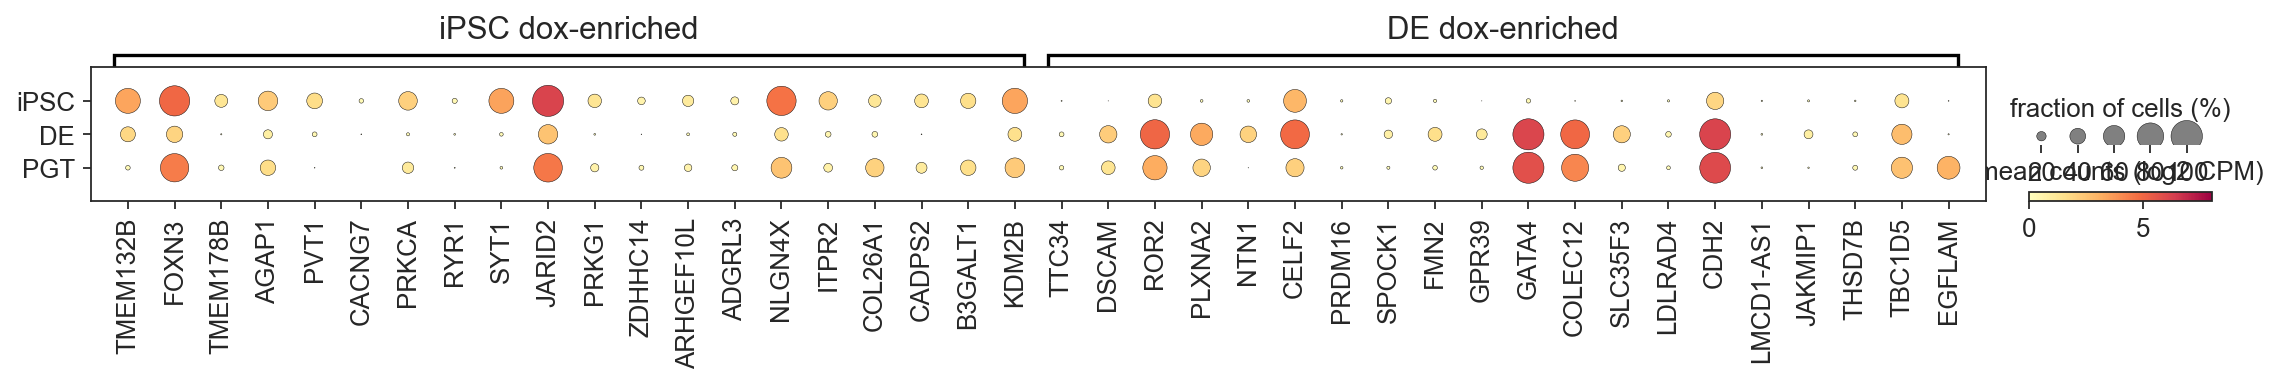

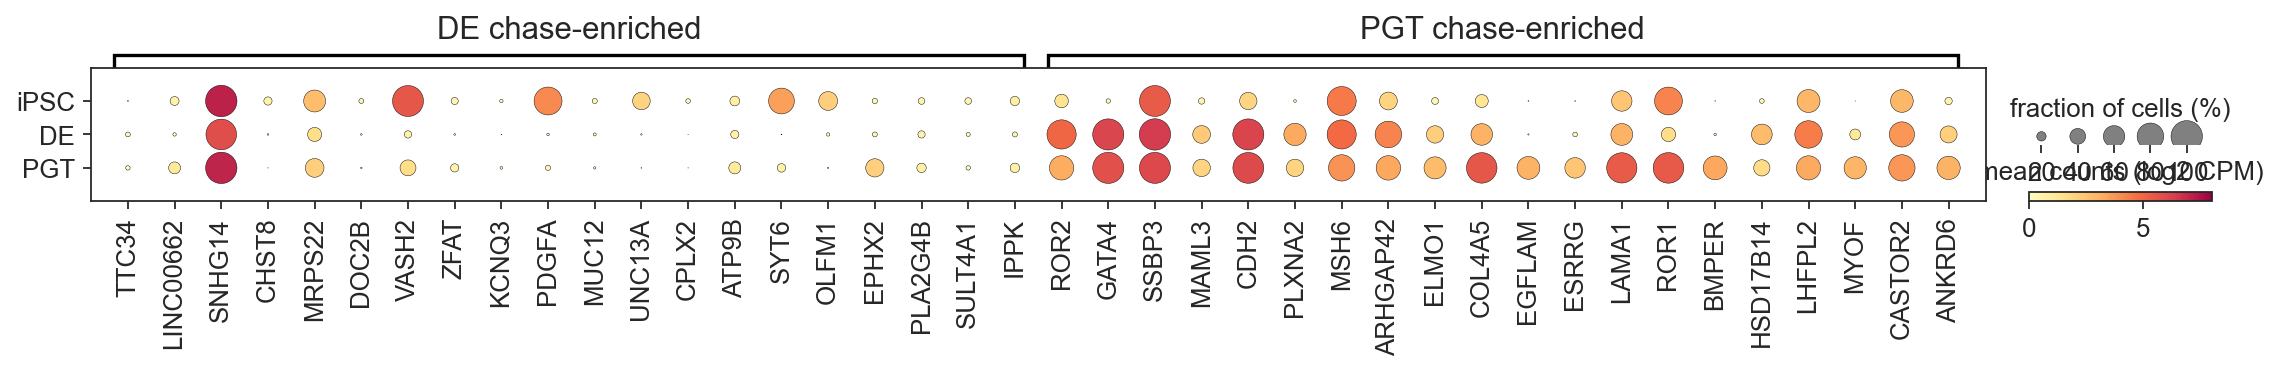

In [12]:
with plt.rc_context({"patch.edgecolor": "black"}):
    for i, (comparison, x, y) in enumerate([["dox", "DE.dox", "iPSC.dox"], ["chase", "PGT.chase", "DE.chase"]]):
        de_df = de_dfs[comparison]
        dotplot_dict = {}
        
        for j, sign in enumerate([y, x]):
            
            # Get list of significant genes
            sign_genes = de_df[de_df["Category"] == sign]["GeneName"]
            sign_genes = [gene for gene in sign_genes if gene in adata_filtered.var_names]
    
            # Add genes to dotplot dict
            dotplot_dict[sign.replace(".", " ") + "-enriched"] = sign_genes[0:20]
            
        sc.pl.dotplot(adata, groupby="Celltype", layer="CPM", log=True, show=False,
                      cmap=sub_spectral_cmap, vmin=0, vmax=8, var_group_rotation=0,
                      size_title="fraction of cells (%)", colorbar_title="mean counts (log2 CPM)",
                      var_names=dotplot_dict, figsize=(17, 1.1))
        
        fig = "b" if i == 0 else "d"
        plt.savefig(f"{output_dir}/SupplementalFigure7{fig}.svg", format="svg")
        plt.show()

## Figure 3c. Violin plot with DCM scores per DCM site for ZFP42 and EOMES

In [13]:
genes = ["EOMES", "ZFP42"]
samples = ["DE.dox", "iPSC.dox"]

gene_counts = counts.loc[counts["GeneName"].isin(genes), samples + ["GeneName"]]
gene_counts = gene_counts.melt(id_vars="GeneName", var_name="Sample", value_name="DCM").explode("DCM")
gene_counts["Sample"] = gene_counts["Sample"].str.replace(".", " ")
display(gene_counts)

for gene in genes:
    print(gene, len(counts.loc[counts["GeneName"] == gene, "iPSC.dox"].iloc[0]))

,GeneName,Sample,DCM
0,EOMES,DE dox,0.061164
0,EOMES,DE dox,0.255168
0,EOMES,DE dox,0.150165
0,EOMES,DE dox,0.143358
0,EOMES,DE dox,0.544027
...,...,...,...
3,ZFP42,iPSC dox,0.070671
3,ZFP42,iPSC dox,0.058618
3,ZFP42,iPSC dox,0.124468
3,ZFP42,iPSC dox,0.0


EOMES 27
ZFP42 45


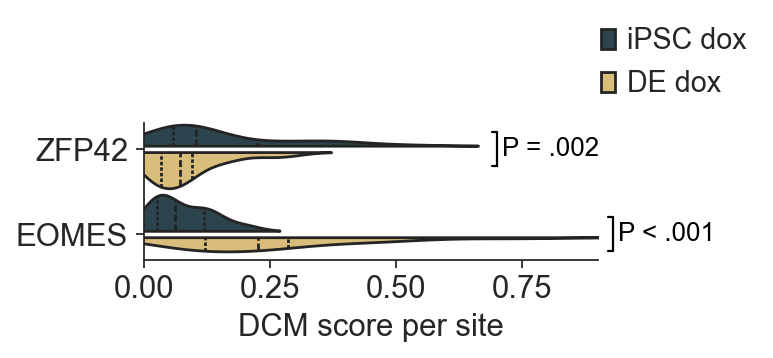

In [14]:
plt.figure(figsize=(5, 1.8))

sns.violinplot(data=gene_counts, y="GeneName", x="DCM", hue="Sample", split=True, width=1, alpha=1,
              palette=[palette["DE"], palette["iPSC"]], gap=.15, inner="quartile")

plt.xlabel("DCM score per site")
plt.ylabel("")
plt.xlim(0, 0.9)
plt.ylim(-0.3, 1.3)

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[::-1], labels[::-1], frameon=False, bbox_to_anchor=(0.95, 1))

## Add p-values
for y1, y2, x, label in [[0.8, 1.2, 0.7, "P = .002"], [-0.2, 0.2, 0.93, "P < .001"]]:
    plt.plot((x, x), (y1, y2), color="black", linewidth=1, clip_on=False)                 # right vertical line
    plt.plot((x-0.01, x), (y1, y1), color="black", linewidth=1, clip_on=False)            # top horizontal line
    plt.plot((x-0.01, x), (y2, y2), color="black", linewidth=1, clip_on=False)            # bottom horizontal line
    plt.text(x+0.01, (y1+y2)/2, label, ha="left", va="center", color="black", fontsize="small", rotation=0)

sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/Figure3c.svg", format="svg")
plt.show()